# Worked Example: Time-Frequency Reward Contrast

## Goal
Morlet TFR on feedback epochs with reward vs no-reward difference map.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from LFPAnalysis import load_lfp
from LFPAnalysis.config import LoadConfig

beh = pd.read_csv(Path('../../data/sample_beh.csv'))
epochs = load_lfp(LoadConfig(path=Path('../../data/sample_feedback_start-epo.fif'), file_format='mne', preload=True))
epochs.metadata = beh[['reward', 'rpe']]
chan = 'racas1-racas2'
freqs = np.arange(4, 30, 4)
reward_tfr = epochs['reward == 1'].copy().pick([chan]).compute_tfr(
    method='morlet', freqs=freqs, n_cycles=freqs / 2.0, average=True, verbose=False
)
loss_tfr = epochs['reward == 0'].copy().pick([chan]).compute_tfr(
    method='morlet', freqs=freqs, n_cycles=freqs / 2.0, average=True, verbose=False
)
diff = reward_tfr.data[0] - loss_tfr.data[0]

Reading /Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_feedback_start-epo.fif ...
    Found the data of interest:
        t =   -1500.00 ...    2500.00 ms
        0 CTF compensation matrices available
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 2 columns


/var/folders/rs/5fd7r4bd4ps2x94n6d46k_t00000gn/T/ipykernel_51243/4238140120.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


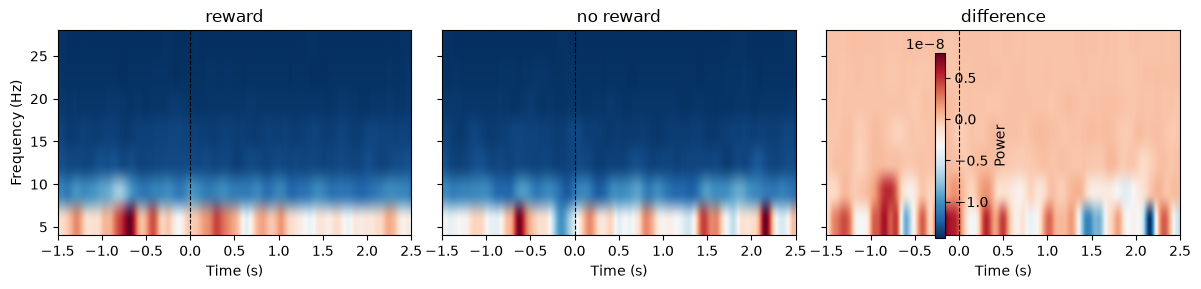

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, data, title in zip(
    axes,
    [reward_tfr.data[0], loss_tfr.data[0], diff],
    ['reward', 'no reward', 'difference'],
):
    im = ax.imshow(data, aspect='auto', origin='lower',
                   extent=[reward_tfr.times[0], reward_tfr.times[-1], freqs[0], freqs[-1]],
                   cmap='RdBu_r')
    ax.axvline(0, color='k', ls='--', lw=0.8)
    ax.set(xlabel='Time (s)', title=title)
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(im, ax=axes, shrink=0.8, label='Power')
fig.tight_layout()
plt.show()

## Next step

Chapter 10 covers connectivity.